In [2]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## READ DATA
train_data = pd.read_csv(r"D:\DataScience\StoreSales\data\train.csv")
stores_data = pd.read_csv(r"D:\DataScience\StoreSales\data\stores.csv")
holidays_events_data = pd.read_csv(r"D:\DataScience\StoreSales\data\holidays_events.csv")
transactions_data = pd.read_csv(r"D:\DataScience\StoreSales\data\transactions.csv")
oil_data = pd.read_csv(r"D:\DataScience\StoreSales\data\oil.csv")


data_contain_date = [train_data, holidays_events_data, transactions_data, oil_data]
for data in data_contain_date:
    data["date"] = pd.to_datetime(data["date"])
    

KIỂM TRA DỮ LIỆU

In [4]:
train_data.info()
train_data.isnull().sum()

holidays_events_data.isna().sum()
transactions_data.isna().sum()

"""check thấy có 43 giá trị nan, vì giá trị xăng
dao động so với các ngày trước là không quá nhiều nên quyết định chọn
fill bằng cách lấy giá xăng ngày trước"""
oil_data["dcoilwtico"] = oil_data["dcoilwtico"].ffill()
oil_data.isnull().sum()
oil_data.to_csv("data\oil.csv", index = False)

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 168.2 MB


PHÂN TÍCH TARGET (SALES)

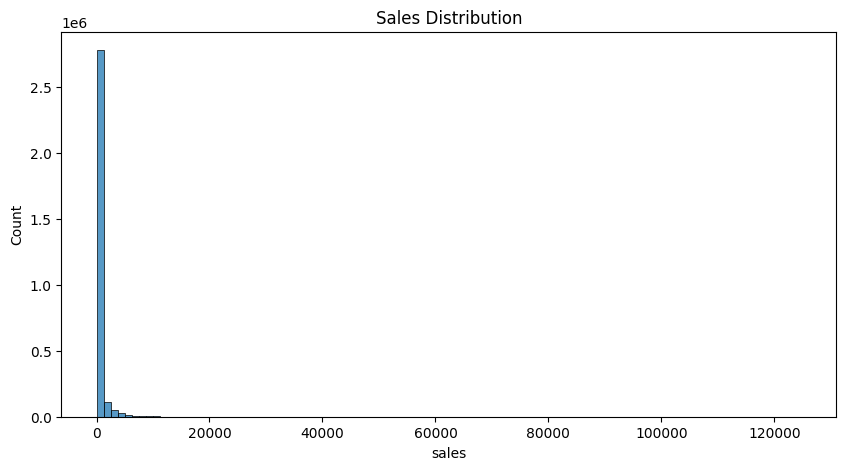

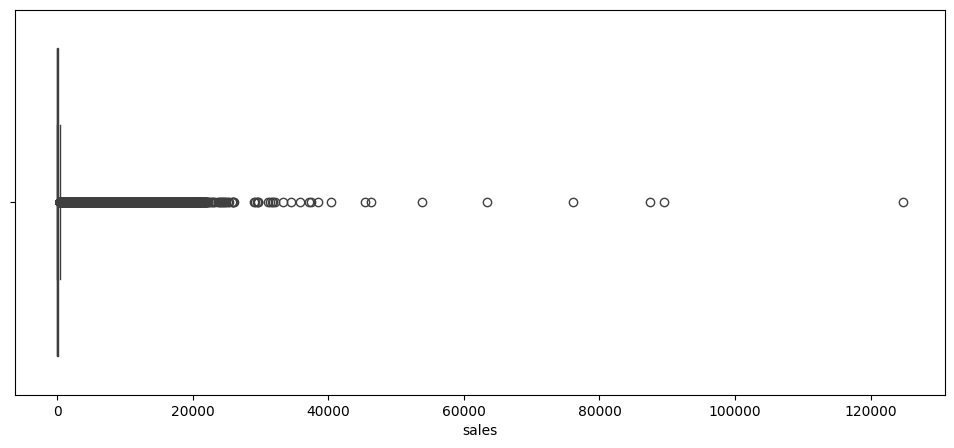

In [5]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(train_data["sales"], bins=100)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x=train_data["sales"])
plt.show()

PHÂN TÍCH DOANH THU THEO THỜI GIAN

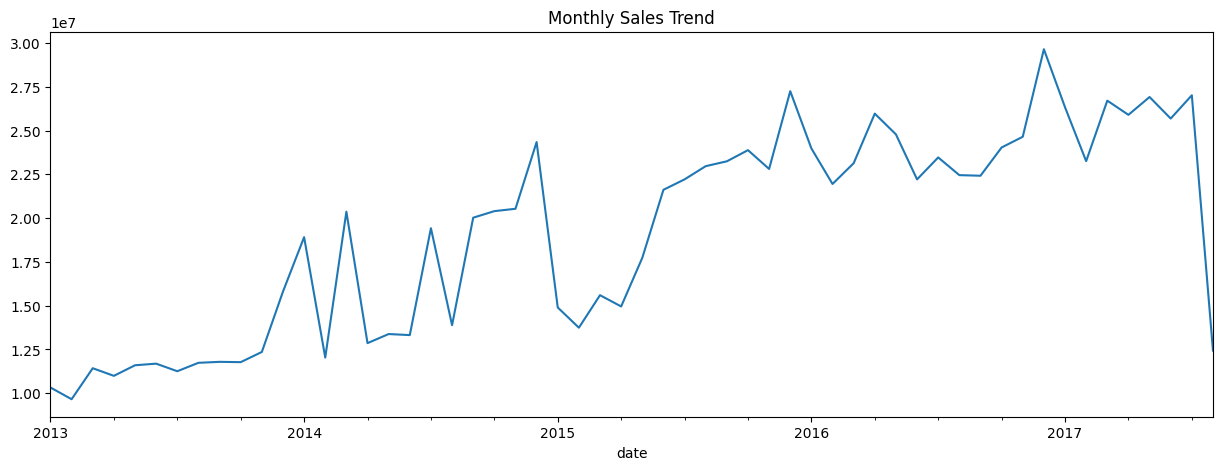

In [6]:
monthly_sales = (
    train_data.groupby(pd.Grouper(key="date",freq="ME"))["sales"]
    .sum()
)

monthly_sales.plot(figsize=(15,5))
plt.title("Monthly Sales Trend")
plt.show()

TỔNG DOANH THU THEO FAMILY

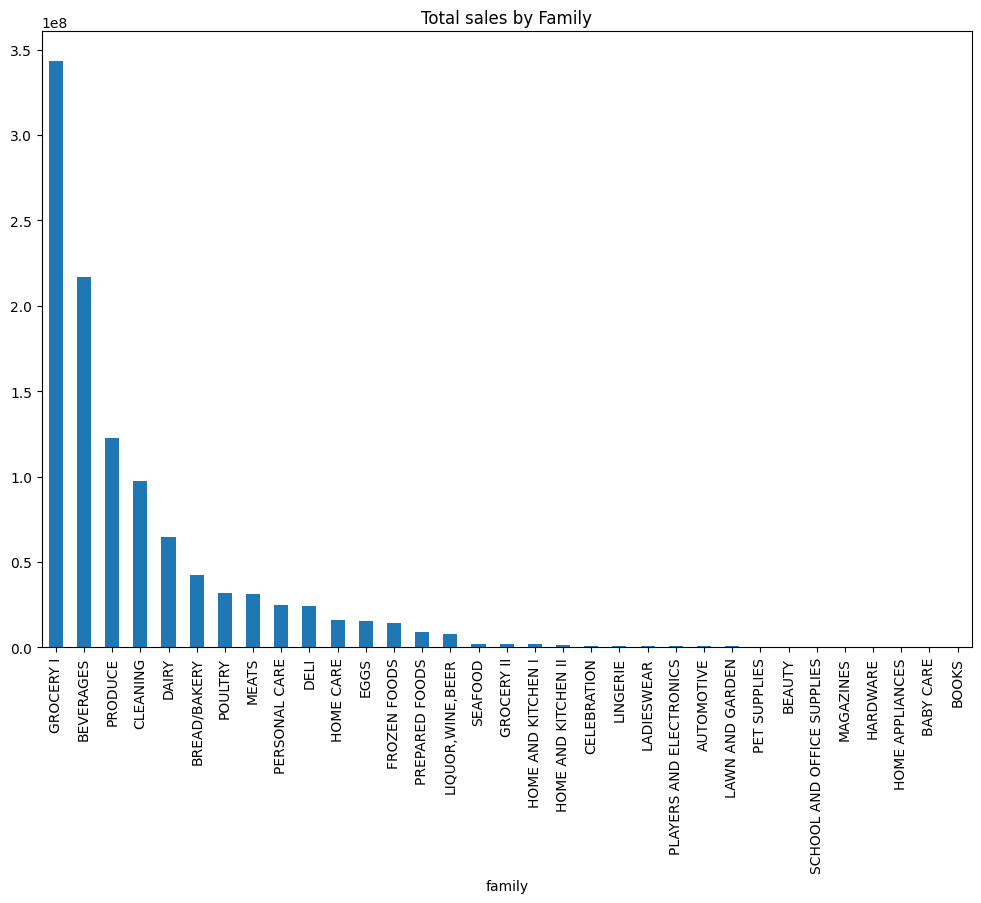

In [7]:
family_sales = train_data.groupby("family")["sales"].sum().sort_values(ascending= False)
plt.figure(figsize = (12,8))
family_sales.plot(kind = "bar")
plt.title("Total sales by Family")
plt.show()

SALES THEO FAMILY QUA THỜI GIAN

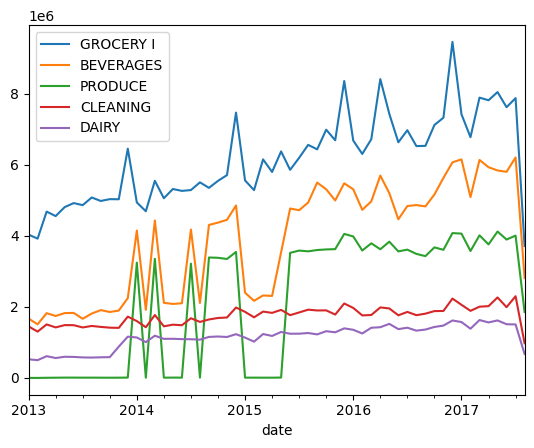

In [8]:
top5 = family_sales.head(5).index

for fam in top5:
    temp = train_data[train_data["family"]==fam]

    monthly = (
        temp.groupby(pd.Grouper(key="date",freq="ME"))
        ["sales"]
        .sum()
    )

    monthly.plot(label=fam)

plt.legend()
plt.show()

SALES THEO THÁNG

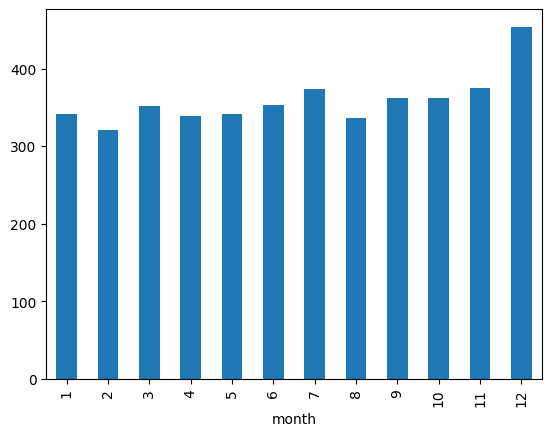

In [9]:
month_sales = train_data.groupby(train_data["date"].dt.month)["sales"].mean()

month_sales.plot(kind = "bar")
plt.xlabel("month")
plt.show()


PHÂN TÍCH TRANSACTIONS CÓ TƯƠNG QUAN VỚI SALES KHÔNG

In [31]:
#Merge transaction với train

df = train_data.merge(
    transactions_data, 
    on= ["date", "store_nbr"],
    how= "left")



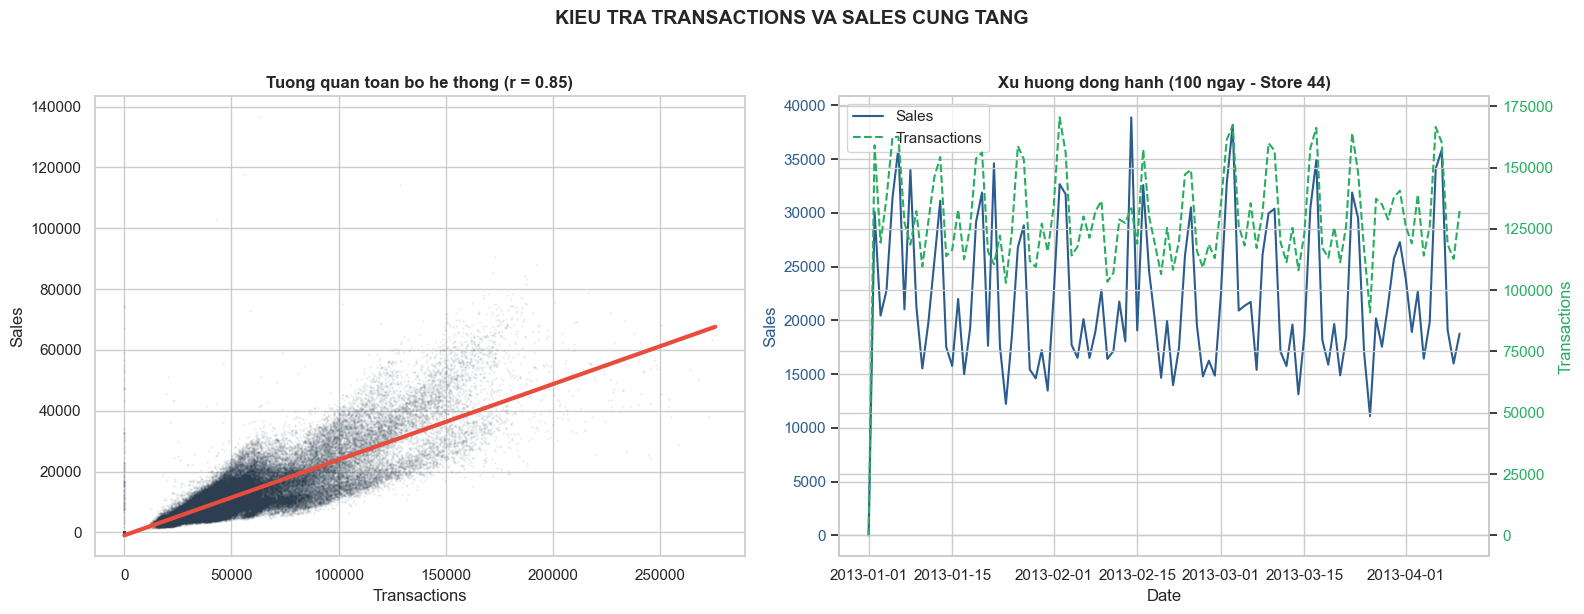

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_grouped = df.groupby(['date', 'store_nbr']).agg({'sales':'sum', 'transactions':'sum'}).reset_index()

sns.regplot(
    data=df_grouped,
    x='transactions',
    y='sales',
    ax=axes[0],
    ci=None,
    scatter_kws={'alpha': 0.05, 'color': '#2c3e50', 's': 1},
    line_kws={'color': '#e74c3c', 'linewidth': 3}
)
corr_val = df_grouped['transactions'].corr(df_grouped['sales'])
axes[0].set_title(f'Tuong quan toan bo he thong (r = {corr_val:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transactions')
axes[0].set_ylabel('Sales')

df_store = df_grouped[df_grouped['store_nbr'] == 44].head(100)

ax2_1 = axes[1]
color_sales = '#2b5c8f'
ax2_1.set_xlabel('Date')
ax2_1.set_ylabel('Sales', color=color_sales)
line1 = ax2_1.plot(df_store['date'], df_store['sales'], color=color_sales, linewidth=1.5, label='Sales')
ax2_1.tick_params(axis='y', labelcolor=color_sales)

ax2_2 = axes[1].twinx()
color_trans = '#27ae60'
ax2_2.set_ylabel('Transactions', color=color_trans)
line2 = ax2_2.plot(df_store['date'], df_store['transactions'], color=color_trans, linewidth=1.5, linestyle='--', label='Transactions')
ax2_2.tick_params(axis='y', labelcolor=color_trans)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2_1.legend(lines, labels, loc='upper left')
axes[1].set_title('Xu huong dong hanh (100 ngay - Store 44)', fontsize=12, fontweight='bold')

plt.suptitle('KIEU TRA TRANSACTIONS VA SALES CUNG TANG', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

PHÂN TÍCH OIL CÓ TƯƠNG QUAN VỚI SALES KHÔNG

In [11]:
#Merge oil với train
df = train_data.merge(
    oil_data,
    on = ["date"],
    how = "left"
)
df[["sales", "dcoilwtico"]].corr()

,sales,dcoilwtico
sales,1.000000,-0.078858
dcoilwtico,-0.078858,1.000000


GIÁ XĂNG THEO THỜI GIAN

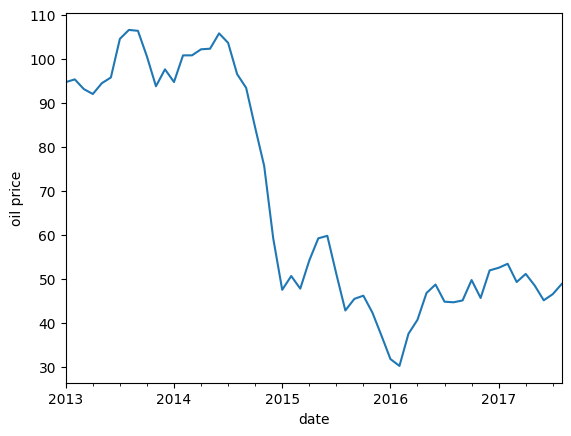

In [12]:
oil_monthly = (
    df.groupby(pd.Grouper(key="date",freq="ME"))["dcoilwtico"]
    .mean()
)

oil_monthly.plot()
plt.ylabel("oil price")
plt.show()

PHÂN TÍCH HOLIDAY 

In [22]:
# 1. Tạo cột logic ngày nghỉ thực tế trên bảng holidays
holidays_events_data['is_real_holiday'] = True
holidays_events_data.loc[(holidays_events_data['type'] == 'Holiday') & (holidays_events_data['transferred'] == True), 'is_real_holiday'] = False
holidays_events_data.loc[holidays_events_data['type'] == 'Work Day', 'is_real_holiday'] = False

# 2. Lọc bớt cột và xóa trùng lặp ngày lễ
holidays_events_data_clean = holidays_events_data[['date', 'type', 'locale', 'is_real_holiday']].drop_duplicates(subset=['date'], keep='first')

# 3. Merge bảng train với bảng lễ đã làm sạch
df_merged = pd.merge(train_data, holidays_events_data_clean, on='date', how='left')

# 4. Điền các giá trị cho ngày thường (ngày không có trong bảng lễ)
df_merged['is_real_holiday'] = df_merged['is_real_holiday'].fillna(False)
df_merged['type'] = df_merged['type'].fillna('Normal Day')
df_merged['locale'] = df_merged['locale'].fillna('None')

# Kiểm tra lại thành quả
print(df_merged.head())


   id       date  store_nbr      family  sales  onpromotion     type  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Holiday   
1   1 2013-01-01          1   BABY CARE    0.0            0  Holiday   
2   2 2013-01-01          1      BEAUTY    0.0            0  Holiday   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Holiday   
4   4 2013-01-01          1       BOOKS    0.0            0  Holiday   

     locale is_real_holiday  
0  National            True  
1  National            True  
2  National            True  
3  National            True  
4  National            True  


C:\Users\TIN\AppData\Local\Temp\ipykernel_8264\3563037406.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


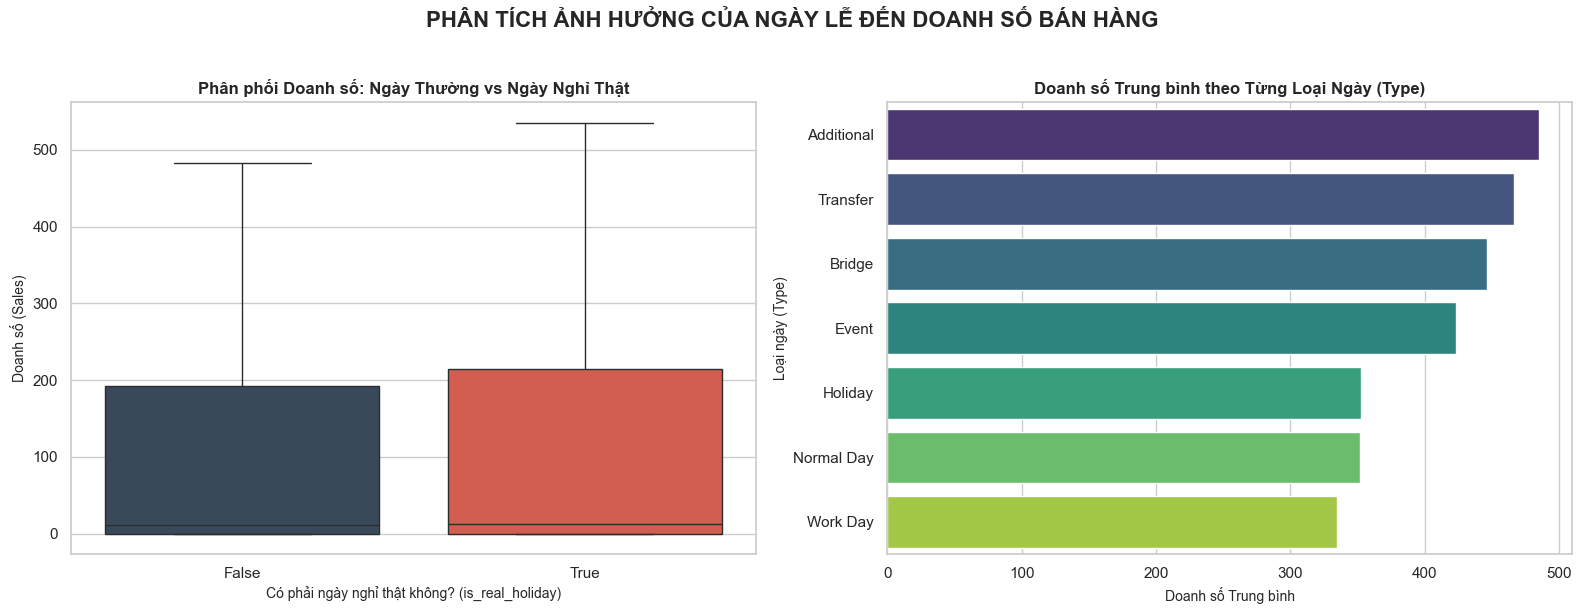

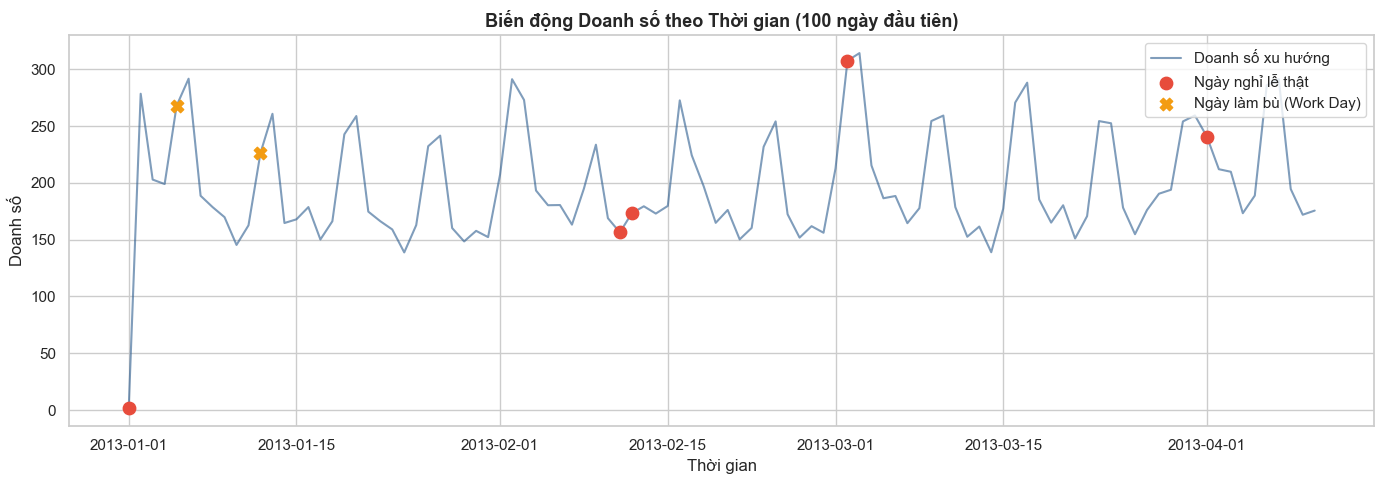

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện chung
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# BIỂU ĐỒ 1: BOXPLOT
# ------------------------------------------------------------------
sns.boxplot(
    data=df_merged, 
    x='is_real_holiday', 
    y='sales', 
    ax=axes[0], 
    palette={'True': '#e74c3c', 'False': '#34495e'},
    showfliers=False
)
axes[0].set_title('Phân phối Doanh số: Ngày Thường vs Ngày Nghỉ Thật', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Có phải ngày nghỉ thật không? (is_real_holiday)', fontsize=10)
axes[0].set_ylabel('Doanh số (Sales)', fontsize=10)


# ------------------------------------------------------------------
# BIỂU ĐỒ 2: BARPLOT 
# ------------------------------------------------------------------
df_type_sales = df_merged.groupby('type', as_index=False)['sales'].mean()
df_type_sales = df_type_sales.sort_values(by='sales', ascending=False)

sns.barplot(
    data=df_type_sales, 
    x='sales', 
    y='type', 
    ax=axes[1],
    hue='type',         
    legend=False,
    palette='viridis'   
)
axes[1].set_title('Doanh số Trung bình theo Từng Loại Ngày (Type)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Doanh số Trung bình', fontsize=10)
axes[1].set_ylabel('Loại ngày (Type)', fontsize=10)

plt.suptitle('PHÂN TÍCH ẢNH HƯỞNG CỦA NGÀY LỄ ĐẾN DOANH SỐ BÁN HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# BIỂU ĐỒ 3: CHUỖI THỜI GIAN (Tự động lấy 100 ngày đầu tiên để tránh bị rỗng)
# ------------------------------------------------------------------
plt.figure(figsize=(14, 5))

# Nhóm dữ liệu theo ngày
df_daily = df_merged.groupby('date').agg({'sales': 'mean', 'is_real_holiday': 'first', 'type': 'first'}).reset_index()

df_period = df_daily.head(100) 

# Vẽ đường doanh số
plt.plot(df_period['date'], df_period['sales'], color='#2b5c8f', alpha=0.6, label='Doanh số xu hướng', linewidth=1.5)

# Chấm các điểm ngày nghỉ thật
real_holidays = df_period[df_period['is_real_holiday'] == True]
if not real_holidays.empty:
    plt.scatter(real_holidays['date'], real_holidays['sales'], color='#e74c3c', s=80, label='Ngày nghỉ lễ thật', zorder=3)

# Đánh dấu các ngày Work Day (Làm bù)
work_days = df_period[df_period['type'] == 'Work Day']
if not work_days.empty:
    plt.scatter(work_days['date'], work_days['sales'], color='#f39c12', marker='X', s=80, label='Ngày làm bù (Work Day)', zorder=3)

plt.title('Biến động Doanh số theo Thời gian (100 ngày đầu tiên)', fontsize=13, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Doanh số')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

PHÂN TÍCH Store Type

In [ ]:
df = df.merge(
    stores_data,
    on = "store_nbr",
    how = "left"
)

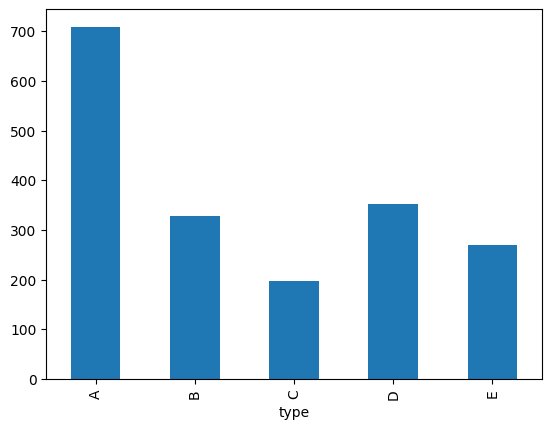

In [ ]:
sales_type = (
    df.groupby("type")["sales"]
    .mean()
)
sales_type.plot(kind="bar")
plt.show()

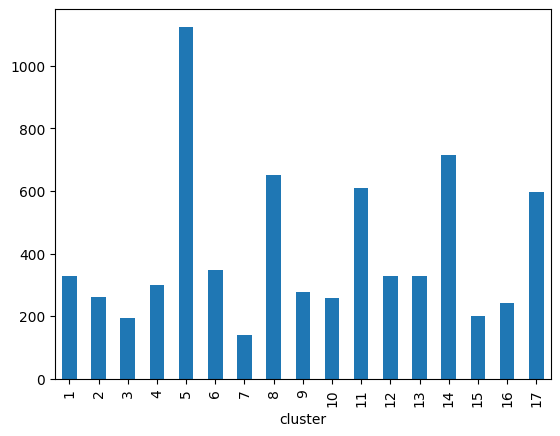

In [ ]:
#Phân tích theo cụm 
cluster_sales = (
    df.groupby("cluster")["sales"]
    .mean()
)
cluster_sales.plot(kind="bar")
plt.show()

PHÂN TÍCH SALES và TRANSACTIONS TRÊN TỪNG CỬA HÀNG

In [17]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 7 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
 6   dcoilwtico   float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(1)
memory usage: 191.1 MB
None


TÓM TẮT DỰA TRÊN BIỂU ĐỒ
- Sales phân bổ nhiều ở khoảng 40000 có 1 vài (rất ít) outliner xuất hiện ở 120000.

- Doanh thu theo thời gian là tăng đều qua các năm.

- Doanh thu theo Family, Grocery chiếm khoảng 1/3 doanh số

- Doanh thu theo top 5 family qua thời gian: grocery 1 tăng đều,  beverage tăng đều nhưng ở năm 2015 có gián đoạn, produce giống beverage. Còn Cleaning và Dairy thì doanh thu không dao động quá nhiều qua các năm.

- Doanh thu theo tháng: Tháng 12 cho thấy doanh thu nổi trội hơn các tháng còn lại.

- Giá xăng theo thời gian: Giá xăng từ 2013-2014 dao động nhẹ, từ 2014 - 2016 giảm mạnh, và từ 2016 - 2017 thì tăng nhẹ.

- Doanh thu trong ngay le: Ngay le cao hon ngay thuong mot chut

- Doanh thu theo loại của hàng: của hàng loại A có doanh thu nổi bật hơn hẳn các loại còn lại.

- Doanh thu theo cụm: Các cụm có doanh thu cao hơn phần còn lại là 5, 8, 10, 14, 17. Trong đó cụm 5 là nổi bật nhất, cao rõ rệt so với top cụm cao.

### CÁC FEATURE CẦN GIỮ VÀ EXPLORE 
##### CẦN GIỮ 
- FAMILY
- MONTH 
- YEAR 
- TYPE
- CLUSTER 
- TRANSACTIONS
##### CẦN EXPLORE
- Lag feature: sales_lag_1, sales_lag_2, sales_lag_3, sales_lag_6, sales_lag_12



In [35]:
import pandas as pd
import numpy as np

# ==================================================
# 1. COPY DATA
# ==================================================

train = train_data.copy()
stores = stores_data.copy()
transactions = transactions_data.copy()
holidays = holidays_events_data.copy()

# ==================================================
# 2. XỬ LÝ HOLIDAYS
# ==================================================

holidays['is_real_holiday'] = True

holidays.loc[
    (holidays['type'] == 'Holiday') &
    (holidays['transferred'] == True),
    'is_real_holiday'
] = False

holidays.loc[
    holidays['type'] == 'Work Day',
    'is_real_holiday'
] = False

holidays_clean = (
    holidays[
        ['date', 'type', 'locale', 'is_real_holiday']
    ]
    .drop_duplicates(subset=['date'], keep='first')
)

# ==================================================
# 3. MERGE TRAIN + HOLIDAYS
# ==================================================

df = pd.merge(
    train,
    holidays_clean,
    on='date',
    how='left'
)

df['is_real_holiday'] = (
    df['is_real_holiday']
    .fillna(False)
)

df['type'] = (
    df['type']
    .fillna('Normal Day')
)

df['locale'] = (
    df['locale']
    .fillna('None')
)

# ==================================================
# 4. MERGE TRANSACTIONS
# ==================================================

df = pd.merge(
    df,
    transactions,
    on=['date', 'store_nbr'],
    how='left'
)

df['transactions'] = (
    df['transactions']
    .fillna(0)
)

# ==================================================
# 5. TẠO FEATURE THỜI GIAN
# ==================================================

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# ==================================================
# 6. TẠO HOLIDAY FEATURE THEO NGÀY
# ==================================================

holiday_dummies = pd.get_dummies(
    df['type'],
    prefix='holiday'
)

df = pd.concat(
    [df, holiday_dummies],
    axis=1
)

# ==================================================
# 7. AGGREGATE THEO FAMILY + THÁNG
# ==================================================

agg_dict = {
    'sales': 'sum',
    'transactions': 'sum',
    'is_real_holiday': 'sum'
}

for col in holiday_dummies.columns:
    agg_dict[col] = 'sum'

monthly_df = (
    df.groupby(
        [
            pd.Grouper(key='date', freq='MS'),
            'family'
        ]
    )
    .agg(agg_dict)
    .reset_index()
)

# ==================================================
# 8. TẠO LẠI FEATURE TIME
# ==================================================

monthly_df['year'] = monthly_df['date'].dt.year
monthly_df['month'] = monthly_df['date'].dt.month
monthly_df['quarter'] = monthly_df['date'].dt.quarter

# ==================================================
# 9. SẮP XẾP
# ==================================================

monthly_df = (
    monthly_df
    .sort_values(
        ['family', 'date']
    )
)

# ==================================================
# 10. LAG FEATURES
# ==================================================

lags = [1, 2, 3, 6, 12]

for lag in lags:

    monthly_df[f'sales_lag_{lag}'] = (
        monthly_df
        .groupby('family')['sales']
        .shift(lag)
    )

# ==================================================
# 11. ROLLING FEATURES
# ==================================================

monthly_df['rolling_mean_3'] = (
    monthly_df
    .groupby('family')['sales']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3)
         .mean()
    )
)

monthly_df['rolling_mean_6'] = (
    monthly_df
    .groupby('family')['sales']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(6)
         .mean()
    )
)

monthly_df['rolling_mean_12'] = (
    monthly_df
    .groupby('family')['sales']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(12)
         .mean()
    )
)

# ==================================================
# 12. ROLLING STD
# ==================================================

monthly_df['rolling_std_3'] = (
    monthly_df
    .groupby('family')['sales']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3)
         .std()
    )
)

monthly_df['rolling_std_6'] = (
    monthly_df
    .groupby('family')['sales']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(6)
         .std()
    )
)

# ==================================================
# 13. FAMILY × MONTH
# ==================================================

monthly_df['family_month'] = (
    monthly_df['family']
    + '_'
    + monthly_df['month'].astype(str)
)

# ==================================================
# 14. XÓA DÒNG THIẾU DO LAG
# ==================================================

monthly_df = monthly_df.dropna()

# ==================================================
# 15. KIỂM TRA
# ==================================================

print(monthly_df.shape)

print(monthly_df.head())

print(monthly_df.columns.tolist())

# ==================================================
# 16. LƯU FILE
# ==================================================

monthly_df.to_csv(
    'final_dataset.csv',
    index=False
)

print("Saved: final_dataset.csv")

(1452, 26)
          date      family    sales  transactions is_real_holiday  \
396 2014-01-01  AUTOMOTIVE   8491.0     2393528.0              54   
429 2014-02-01  AUTOMOTIVE   7563.0     2278167.0               0   
462 2014-03-01  AUTOMOTIVE  10115.0     2545427.0             162   
495 2014-04-01  AUTOMOTIVE   8426.0     2455666.0             270   
528 2014-05-01  AUTOMOTIVE   8075.0     2503262.0             270   

     holiday_Additional  holiday_Bridge  holiday_Event  holiday_Holiday  \
396                   0               0              0               54   
429                   0               0              0                0   
462                   0               0              0              162   
495                   0               0              0              270   
528                  54               0             54              162   

     holiday_Normal Day  ...  sales_lag_2  sales_lag_3  sales_lag_6  \
396                1620  ...       7166.0       6803